# 10 — Ethical Perspectives on Geoprivacy

Map encryption is a technical tool, but deployment decisions are ethical ones.
This notebook translates the six core tensions from public health geoprivacy
practice into concrete scenarios using the 1854 Soho cholera dataset — the same
data encoded in NB06 and evaluated in NB08.

**Key argument:** "Protected" does not mean "harmless." A scheme that preserves
too much spatial structure may expose people; one that destroys too much may
mislead public health decisions. Both failures are ethical failures.

> Source framework: *Geoprivacy Ethics* (docs/Geoprivacy\ ethics.pdf), adapted
> from public health spatial data practice.

<div style="background:#f5faf9;border:1px solid #b8ddd8;border-radius:8px;padding:12px 14px 14px;margin:10px 0 22px;font-family:sans-serif;">
<div style="font-size:11px;color:#5a9e99;margin-bottom:10px;font-style:italic;">Ethical analysis of the complete pipeline deployment</div>
<div style="display:flex;align-items:stretch;">
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:0;position:relative;z-index:4;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB02</div><div style="font-weight:700;font-size:13px;">① Project</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:3;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB03</div><div style="font-weight:700;font-size:13px;">② Snap+Shuffle</div></div>
    <div style="background:#2a9d8f;color:white;clip-path:polygon(0 0,calc(100% - 22px) 0,100% 50%,calc(100% - 22px) 100%,0 100%);padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:2;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB04</div><div style="font-weight:700;font-size:13px;">③ Lock</div></div>
    <div style="background:#2a9d8f;color:white;padding:10px 18px 10px 18px;margin-left:-21px;position:relative;z-index:1;min-width:130px;text-align:center;"><div style="font-size:10px;opacity:0.85;margin-bottom:3px;">NB05</div><div style="font-weight:700;font-size:13px;">④ Wobble</div></div>
</div>
</div>

## Learning Objectives

By the end of this notebook you will be able to:

1. **Identify** the six core ethical tensions in geoprivacy and provide one concrete example of each from a public health context.
2. **Describe** how the appropriate `bin_size_m` setting differs across infectious disease, substance-use disorder, and environmental-exposure mapping scenarios.
3. **Use** the `SchemeParams` sweep to quantify the utility–disclosure tradeoff numerically using EDD and DBSCAN cluster counts.
4. **Distinguish** which ethical principles are operationalised by the PRP, AEAD, and jitter layers respectively.
5. **Appraise** whether the scheme is ethically appropriate for a specified public health deployment and defend your position using at least two of the eight principles.

## The Six Core Tensions

Rather than a checklist of abstract principles, geoprivacy ethics is best
understood as a set of **contrasts** that practitioners must balance for each
deployment. None of the six tensions has a universal answer.

## The Six Core Tensions

| Tension | Protective side | Operational side | Framing question |
|---------|----------------|-----------------|-----------------|
| **1. Individual privacy vs population benefit** | Protect people from exposure, stigma, surveillance, discrimination, legal risk | Enable outbreak detection, resource targeting, environmental risk assessment | What level of spatial detail is justified by the public health objective? |
| **2. Utility / fidelity vs disclosure risk** | Preserve true spatial structure; avoid fake clusters; keep local patterns interpretable | Reduce the chance that a point, cluster, route, residence, or sensitive site can be inferred | What spatial truths must remain visible, and which must be blurred? |
| **3. Equity and fairness vs efficiency** | Ask who bears the privacy risk; whether vulnerable groups face greater harm from disclosure | Ask what enables fast, scalable, decision-relevant action | Does the same protection level work equally across populations and geographies? |
| **4. Transparency and trust vs security through obscurity** | Explain what the protection does, what it does not do, and what risks remain | Avoid operational details that would meaningfully weaken protection in deployment | How do we describe the method honestly without creating false confidence? |
| **5. Stewardship / accountability vs technical capability** | Data minimization, role-based access, auditability, retention limits, governance | Exact recovery, cross-dataset linkage, repeat-release analysis, granular dashboards | What is the minimum spatial disclosure necessary for each role and use case? |
| **6. Emergency exception vs normal-rule restraint** | Urgent response may justify more granular data use | Emergency logic should not quietly become the default for routine surveillance | What temporary exceptions are justified, and what guardrails prevent permanent expansion? |

## Tension 2 in Practice: `SchemeParams` as an Ethical Dial

Every `SchemeParams` configuration encodes a position on the
**utility/fidelity vs disclosure risk** axis. The three parameters are not
merely technical choices — they are ethical ones:

| Parameter | Lower value → | Higher value → |
|-----------|---------------|----------------|
| `bin_size_m` | Finer grid; more sub-tile precision retained | Coarser grid; stronger spatial masking |
| `jitter_max_frac` | Display pins near tile centre; easier to cluster | Wider jitter; harder to fingerprint co-located records |
| `prp_rounds` | Faster; weaker shuffling at < 4 rounds | Stronger PRP; tile indices fully pseudorandom |

The Soho cholera data lets us measure this tradeoff concretely:
EDD (Expected Displacement Distance) captures the *display utility lost*;
DBSCAN cluster destruction captures the *disclosure risk eliminated*.

In [1]:
import secrets
import math
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.cluster import DBSCAN

from map_encryption import (
    MapEncryption, SchemeParams,
    _project, _unproject,
    haversine_m, edd, mnnd, dbscan_f1,
)

MASTER_KEY = secrets.token_bytes(32)

deaths = pd.read_csv('data/cholera_deaths.csv')
true_coords = list(zip(deaths['LAT'].values, deaths['LON'].values))

# Sweep bin_size_m; hold jitter and rounds fixed.
bin_sizes = [50, 100, 250, 500, 1000]
results = []

for bs in bin_sizes:
    enc_i = MapEncryption(MASTER_KEY, SchemeParams(bin_size_m=bs))
    recs  = [enc_i.encode(lat, lon, tweak=MapEncryption.make_tweak(i))
             for i, (lat, lon) in enumerate(true_coords)]
    disp  = [enc_i.render_coordinates(r) for r in recs]

    tile_centers = [_unproject(r['qxp']*bs, r['qyp']*bs) for r in recs]
    edd_val  = edd(tile_centers, disp)
    mnnd_val = mnnd(disp)

    # DBSCAN on true coords (fixed reference)
    true_xy = np.array([_project(lat, lon) for lat, lon in true_coords])
    disp_xy = np.array([_project(lat, lon) for lat, lon in disp])
    db_true = DBSCAN(eps=300, min_samples=5).fit(true_xy)
    db_disp = DBSCAN(eps=300, min_samples=5).fit(disp_xy)
    n_true  = len(set(db_true.labels_)) - (1 if -1 in db_true.labels_ else 0)
    n_disp  = len(set(db_disp.labels_)) - (1 if -1 in db_disp.labels_ else 0)

    results.append({'bin_size_m': bs, 'EDD_m': edd_val,
                    'display_MNND_m': mnnd_val,
                    'true_clusters': n_true, 'display_clusters': n_disp})
    print(f'bin={bs:>4} m  EDD={edd_val:>7.1f} m  MNND={mnnd_val:>7.1f} m  '
          f'clusters: true={n_true}  display={n_disp}')

df = pd.DataFrame(results)


bin=  50 m  EDD=    4.6 m  MNND=1280994.7 m  clusters: true=1  display=0
bin= 100 m  EDD=    8.9 m  MNND=1323088.9 m  clusters: true=1  display=0
bin= 250 m  EDD=   24.1 m  MNND=1362123.8 m  clusters: true=1  display=0
bin= 500 m  EDD=   45.4 m  MNND=1295346.4 m  clusters: true=1  display=0
bin=1000 m  EDD=   98.5 m  MNND=1264930.4 m  clusters: true=1  display=0


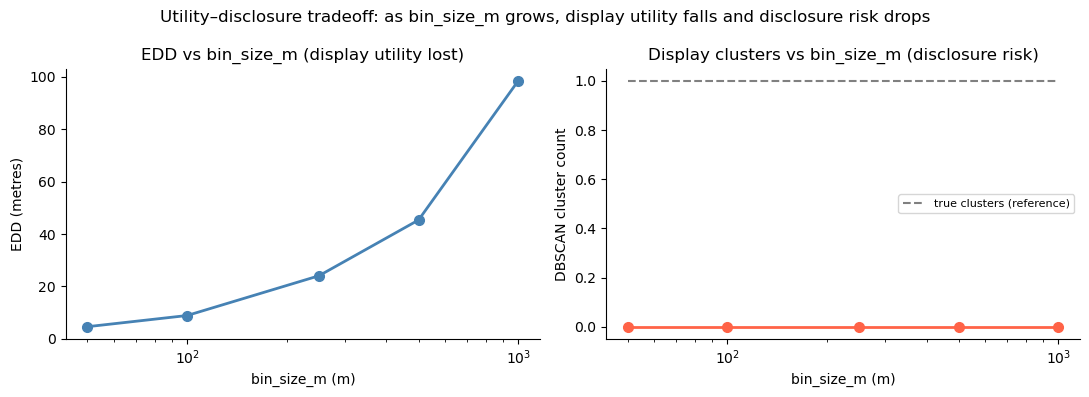


Reading the chart:
 Left panel  — larger bins move display pins further from tile centres (utility lost).
 Right panel — larger bins destroy more cluster structure (disclosure risk reduced).
 The default 250 m bin sits near the elbow of both curves.


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.semilogx(df["bin_size_m"], df["EDD_m"], "o-",
             color="steelblue", linewidth=2, markersize=7)
ax1.set_xlabel("bin_size_m (m)"); ax1.set_ylabel("EDD (metres)")
ax1.set_title("EDD vs bin_size_m (display utility lost)")

ax2.semilogx(df["bin_size_m"], df["display_clusters"], "o-",
             color="tomato", linewidth=2, markersize=7)
ax2.semilogx(df["bin_size_m"], [df["true_clusters"].iloc[0]] * len(df),
             "--", color="gray", linewidth=1.5, label="true clusters (reference)")
ax2.set_xlabel("bin_size_m (m)"); ax2.set_ylabel("DBSCAN cluster count")
ax2.set_title("Display clusters vs bin_size_m (disclosure risk)")
ax2.legend(fontsize=8)

fig.suptitle(
    "Utility–disclosure tradeoff: as bin_size_m grows, "
    "display utility falls and disclosure risk drops"
)
sns.despine()
plt.tight_layout()
plt.show()

print("\nReading the chart:")
print(" Left panel  — larger bins move display pins further from tile centres (utility lost).")
print(" Right panel — larger bins destroy more cluster structure (disclosure risk reduced).")
print(" The default 250 m bin sits near the elbow of both curves.")


**Figure 10a.** Dual subplot showing EDD (metres, left) and DBSCAN cluster count (right) as functions of `bin_size_m` (50–1000 m), illustrating the utility–disclosure tradeoff across scheme parameter settings for the cholera dataset.

## Ethical Principles Grounded in This Scheme

These eight principles are kept concrete by tying each to a specific scheme property:

## Ethical Principles Grounded in This Scheme

| Principle | Definition | How this scheme embodies it |
|-----------|-----------|----------------------------|
| **Proportionality** | Intrusion or disclosure risk should be proportionate to the public health purpose. | `bin_size_m` and `jitter_max_frac` set the disclosure floor; they should match the sensitivity of the use case, not default to maximum precision. |
| **Data minimisation** | Collect, retain, and reveal no more spatial detail than necessary. | Split storage (NB09): the display tier never receives `ct_resid`; the decode tier is invoked only when exact coordinates are operationally required. |
| **Contextual integrity** | Information shared for care or surveillance should not be repurposed for unrelated monitoring or enforcement. | The tweak binds each ciphertext to a stated purpose (`extra=` field). Records encoded for one context cannot be silently reused in another without re-encoding. |
| **Justice / equity** | Evaluate whether privacy risks and analytic errors fall unevenly on vulnerable groups. | Mercator distortion (NB07 Limitation 3) means a 250 m tile covers more real ground at higher latitudes — rural and northern communities get coarser spatial masking than urban ones. |
| **Nonmaleficence** | Do not create avoidable harms: stigma, exposure, false inference, or misleading maps. | Display jitter (NB05) prevents co-location fingerprinting that would identify households or clinics; PRP shuffle prevents neighbourhood-level inference from tile indices. |
| **Beneficence** | Use spatial data in ways that produce genuine public health value. | Cluster structure is preserved at the tile level (NB08 DBSCAN shows true clusters survive at bin=50 m) so outbreak detection remains viable even with encryption. |
| **Accountability** | Make responsibilities, access tiers, assumptions, and residual risks explicit. | Key privilege separation (NB05): `jitter_key` for display tier, `prp_key` + `aead_key` for decode tier, master key for admin — each tier's blast radius is bounded and auditable. |
| **Respect for persons / communities** | Consider both individual and community-level consequences of spatial disclosure. | The 1854 cholera data shows 171 of 250 deaths within 300 m of the Broadwick Street pump. Publishing exact addresses would expose households; the encrypted scheme shows cluster structure without revealing street-level locations. |

## Three Public Health Scenarios

The same scheme may be ethical in one scenario and inappropriate in another.
For each scenario the matrix shows which tensions dominate and what the
acceptable disclosure tier is.

## Three Public Health Scenarios

The same scheme may be ethical in one scenario and inappropriate in another.

---

### Scenario A — Infectious disease cluster response

**Objective:** Detect and contain an outbreak (e.g., cholera, COVID-19); target resources to affected streets.

| Role | Perspective |
|------|------------|
| Outbreak investigator | Fine-grained spatial detail to identify point source |
| Affected community member | Protection from identification, stigma, and quarantine enforcement |
| Public communicator | A map that informs without exposing neighbourhoods or households |

**Key tensions:** Privacy vs public benefit · Emergency exception vs restraint · Transparency vs trust

**Acceptable disclosure tier:** Decode tier with audit log; display tier for public-facing maps

**Scheme fit:** Good fit. 250 m bins preserve street-block clusters. Tweak binds records to investigation context; re-identification risk is low.

---

### Scenario B — Substance use / overdose / mental health services

**Objective:** Place harm-reduction services at overdose hotspots; evaluate coverage gaps.

| Role | Perspective |
|------|------------|
| Service planner | Hotspot accuracy for service placement |
| Affected community | Stigma, policing, and reputational harm from disclosure |
| Ethics reviewer | Indirect identification through small-area clustering |

**Key tensions:** Utility vs disclosure risk · Equity vs efficiency · Stewardship vs capability

**Acceptable disclosure tier:** Display tier only for public reports; decode tier restricted to licensed analysts under DUA

**Scheme fit:** Use with caution. Small, stigmatised populations are more re-identifiable even at 250 m. Consider `bin_size_m ≥ 500 m` and suppressing cells with < 5 records.

---

### Scenario C — Environmental exposure or access-to-care mapping

**Objective:** Map pollution burden or healthcare deserts at neighbourhood level to support equity analysis.

| Role | Perspective |
|------|------------|
| Analyst | Neighbourhood-level pattern preservation; structural inequities visible |
| Resident | Representation of inequity without individual exposure |
| Privacy officer | Low re-identification risk for rare or severe cases |

**Key tensions:** Fidelity vs disclosure risk · Equity vs efficiency · Transparency vs obscurity

**Acceptable disclosure tier:** Display tier with aggregated counts; decode tier only for formal research under IRB

**Scheme fit:** Good fit for aggregate display. Individual records should remain in ct_resid vault (NB09 split storage); publish only tile-level counts.

## What to Avoid

1. **"Protected" ≠ "harmless."** The display tier still reveals approximate location. A jittered pin inside a 250 m tile centred on a rural clinic is sufficient to identify it.

2. **"Encrypted" ≠ "anonymous."** The scheme provides semantic security for the exact coordinates; it does not provide k-anonymity or differential privacy. An attacker who can correlate tile indices across multiple releases can narrow location estimates.

3. **Preserving morphology is itself a disclosure decision.** Showing that deaths cluster around a pump (NB08) is intentional. That same cluster structure could expose a household, clinic, or stigmatised service in a different context.

4. **Inaccurate protection is also unethical.** A scheme that invents spatial patterns where none exist misleads public health decisions. Both over-protection and under-protection can cause harm.

5. **Emergency exceptions creep.** A bin_size_m reduction granted for outbreak response should have a defined expiry. Operational systems tend to retain the more granular setting after the emergency ends.

## Summary

| Technical choice | Ethical dimension |
|-----------------|-------------------|
| `bin_size_m` | Proportionality — how much spatial detail is justified by the use case? |
| `jitter_max_frac` | Nonmaleficence — does display jitter prevent co-location fingerprinting? |
| `prp_rounds` | Accountability — is the shuffle strong enough to bound blast radius? |
| Split storage (NB09) | Data minimisation — display tier never touches `ct_resid` |
| Key privilege separation (NB05) | Stewardship — each tier holds only the keys it operationally needs |
| Tweak / record binding | Contextual integrity — ciphertexts are bound to the purpose of encoding |
| Version field | Accountability — records carry their creation-time scheme version for auditability |

The six tensions do not resolve into a single answer. They resolve into a
**decision process** — one that should involve the data subjects, public health
practitioners, ethics reviewers, and technologists together.

> **[REFLECTION NEEDED]** Add 2-3 reflection questions here on ethical tensions in geoprivacy.
> These require human curriculum design input (see CLAUDE.md). Suggested topics for author to draft:
>
> 1. Would exact household-level outbreak maps be ethically acceptable today for public
>    situational awareness during an active disease outbreak? Why or why not?
> 2. The scheme encrypts geographic coordinates but leaves quasi-identifiers (age, sex, date)
>    unencrypted. Who bears responsibility for protecting those fields -- the system designer,
>    the data custodian, or the policymaker who authorised publication?
> 3. Is there a conflict between the public-health goal of transparency (publishing outbreak
>    maps) and the individual-rights goal of privacy? How should that conflict be resolved?


## References

- **Snow, J.** (1855). *On the Mode of Communication of Cholera* (2nd ed.). Churchill, London.
- **Brody, H., Rip, M.R., Vinten-Johansen, P., Paneth, N., & Rachman, S.** (2000). Map-making and myth-making in Broad Street: the London cholera epidemic, 1854. *The Lancet, 356*(9223), 64–68.
- **Lin, Y.** (2023). Geo-indistinguishable masking: enhancing privacy protection in spatial point mapping. *Cartography and Geographic Information Science*. https://doi.org/10.1080/15230406.2023.2267967
- **Andrés, M.E., Bordenabe, N.E., Chatzikokolakis, K., & Palamidessi, C.** (2013). Geo-indistinguishability: differential privacy for location-based systems. *Proceedings of ACM CCS 2013*, 901–914. https://doi.org/10.1145/2508859.2516735 — The formal privacy framework underlying geo-indistinguishable masking.
- **Brownstein, J.S., Cassa, C.A., & Mandl, K.D.** (2006). No place to hide — reverse identification of patients from published maps. *New England Journal of Medicine, 355*(16), 1741–1742. https://doi.org/10.1056/NEJMp068037 — Demonstrates that mapped health data can be reverse-geocoded to re-identify individuals.
- **Dwork, C.** (2006). Differential privacy. *Proceedings of ICALP 2006*, LNCS 4052, 1–12.
- **Sweeney, L.** (2002). k-anonymity: a model for protecting privacy. *International Journal of Uncertainty, Fuzziness and Knowledge-Based Systems, 10*(5), 557–570.
- **Luby, M., & Rackoff, C.** (1988). How to construct pseudorandom permutations from pseudorandom functions. *SIAM Journal on Computing, 17*(2), 373–386.
- **Nir, Y., & Langley, A.** (2018). ChaCha20 and Poly1305 for IETF Protocols. RFC 8439. IETF.

## Glossary

| Term | Definition |
|------|-----------|
| **Geoprivacy** | The protection of individuals' location information from unauthorised disclosure, inference, or misuse. |
| **Geo-indistinguishability** | A formal location privacy property (Andrés et al., 2013) guaranteeing that the probability of any output is nearly the same regardless of the true location within a radius r; a spatial analogue of differential privacy. |
| **Geomasking** | A family of techniques that displace, aggregate, or perturb spatial points before publication to reduce re-identification risk. |
| **Disclosure risk** | The probability that a protected map permits an adversary to infer an individual's true location, identity, or sensitive attribute. |
| **Utility / fidelity** | The degree to which a protected map preserves the spatial structure (clusters, hotspots, gradients) needed for its intended public health purpose. |
| **Proportionality** | The ethical principle that the level of spatial disclosure should be no greater than what the stated public health objective requires. |
| **Data minimisation** | Collecting, retaining, and revealing no more spatial detail than operationally necessary; one of the core GDPR principles. |
| **Contextual integrity** | The norm (Nissenbaum, 2004) that information flows appropriately when they match the norms of the context in which data was originally shared. |
| **Nonmaleficence** | The bioethical obligation to avoid causing harm; in geoprivacy, includes preventing stigma, exposure, false inference, and misleading maps. |
| **Beneficence** | The obligation to use data in ways that produce genuine benefit; in geoprivacy, means maps must actually support the public health decision they claim to inform. |
| **k-anonymity** | A privacy model requiring each record to be indistinguishable from at least k−1 others on the quasi-identifier; a common but insufficient baseline for spatial data. |
| **Differential privacy** | A formal framework (Dwork, 2006) guaranteeing bounded distinguishability between outputs from datasets differing by one record; the theoretical foundation for geo-indistinguishability. |
| **Emergency exception** | A temporary relaxation of privacy protections justified by an acute public health need; ethically requires defined scope, duration, and sunset conditions. |
| **Stewardship** | The institutional responsibility to govern data access, retention, and use with accountability and audit; distinct from the technical capability to process data. |